# Author: Yaseer Sabir
## **Table of Contents**
1) Quick sort
2) Optimized bubble sort
3) Combined Two sorts
4) Time efficiency correlation to k value
5) Extra Credit 

In [26]:
'''
Description:
    This program implements the QuickSort algorithm to sort a list of integers.
    QuickSort is a divide-and-conquer algorithm that partitions an array around a pivot element,
    recursively sorting the left and right sublists.

Time Complexity:
    Average Case: O(n log n)
    Worst Case:   O(n^2)
'''

import random
import time

def quicksort(arr):
    """
    Recursively sorts a list using the QuickSort algorithm.

    Parameters:
        arr (list): The list of integers to sort.

    Returns:
        list: A new sorted list.
    """
    # Base case: if list has 0 or 1 element, it is already sorted
    if len(arr) <= 1:
        return arr

    # Select a pivot (middle element is common and simple)
    pivot = arr[len(arr) // 2]

    # Partition the array into three lists:
    # elements less than pivot, equal to pivot, and greater than pivot
    left = [x for x in arr if x < pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]

    # Recursively sort the left and right parts, then combine results
    return quicksort(left) + middle + quicksort(right)


# ---------------- TEST PROGRAM ----------------
if __name__ == "__main__":
    # Generate a small list of 20 random integers between 1 and 100
    small_data = [random.randint(1, 100) for _ in range(20)]
    print("Original (20 integers):", small_data)

    # Sort using QuickSort and display results
    print("Sorted:", quicksort(small_data))

    # Generate a larger dataset of 1,000 random integers between 1 and 10,000
    large_data = [random.randint(1, 10000) for _ in range(1000)]

    # Measure runtime performance
    start = time.time()
    quicksort(large_data)
    end = time.time()

    # Display elapsed time
    print(f"\nQuicksort completed for 1,000 integers in {end - start:.6f} seconds.")


Original (20 integers): [45, 14, 23, 46, 40, 46, 12, 83, 9, 51, 42, 38, 12, 75, 87, 43, 23, 92, 88, 67]
Sorted: [9, 12, 12, 14, 23, 23, 38, 40, 42, 43, 45, 46, 46, 51, 67, 75, 83, 87, 88, 92]

Quicksort completed for 1,000 integers in 0.000999 seconds.


In [28]:
"""
Author: Yaseer Sabir
Description:
    This program implements an optimized version of the Bubble Sort algorithm.
    The optimization stops the algorithm early if no swaps occur in a pass,
    which significantly improves performance for nearly-sorted lists.

Time Complexity:
    Best Case:    O(n)   (when the list is already sorted)
    Average Case: O(n^2)
    Worst Case:   O(n^2)
"""

import random
import time

def optimized_bubble_sort(arr):
    """
    Sorts a list using an optimized version of the Bubble Sort algorithm.

    Parameters:
        arr (list): The list of integers to sort.

    Returns:
        list: The sorted list.
    """
    n = len(arr)

    # Outer loop for each pass through the list
    for i in range(n - 1):
        swapped = False  # Flag to detect if any swaps occur during this pass

        # Inner loop compares adjacent elements and swaps if necessary
        for j in range(n - i - 1):  # Last i elements are already sorted
            if arr[j] > arr[j + 1]:
                # Swap elements if they are out of order
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                swapped = True

        # If no swaps occurred, the list is already sorted → exit early
        if not swapped:
            break

    return arr


# ---------------- TEST PROGRAM ----------------
if __name__ == "__main__":
    # Generate a small dataset of 20 random integers for demonstration
    small_data = [random.randint(1, 100) for _ in range(20)]
    print("Original (20 integers):", small_data)

    # Sort and display results
    print("Sorted:", optimized_bubble_sort(small_data[:]))  # [:] copies the list

    # Generate a larger dataset of 1,000 random integers between 1 and 10,000
    large_data = [random.randint(1, 10000) for _ in range(1000)]

    # Measure runtime performance
    start = time.time()
    optimized_bubble_sort(large_data[:])
    end = time.time()

    # Display elapsed time
    print(f"\nOptimized Bubble Sort completed for 1,000 integers in {end - start:.6f} seconds.")


Original (20 integers): [24, 41, 82, 12, 21, 72, 74, 58, 50, 62, 64, 22, 4, 91, 19, 4, 35, 97, 88, 45]
Sorted: [4, 4, 12, 19, 21, 22, 24, 35, 41, 45, 50, 58, 62, 64, 72, 74, 82, 88, 91, 97]

Optimized Bubble Sort completed for 1,000 integers in 0.058137 seconds.


In [30]:
"""
Author” Yaseer Sabir
Description:
    This program combines QuickSort and Optimized Bubble Sort into a hybrid sorting algorithm.
    The algorithm uses QuickSort for large partitions, but switches to Bubble Sort
    when the partition size is less than or equal to a threshold value k.

    The program measures runtime performance for different k values
    to determine which produces the fastest sorting time.

Time Complexity:
    Average: O(n log n)
    Worst:   O(n^2)
"""

import random
import time

# -------------------------------------------------------------------
# Optimized Bubble Sort (used for small subarrays)
# -------------------------------------------------------------------
def optimized_bubble_sort(arr):
    """Sorts a list using optimized bubble sort (stops early if no swaps)."""
    n = len(arr)
    for i in range(n - 1):
        swapped = False
        for j in range(n - i - 1):
            if arr[j] > arr[j + 1]:
                # Swap adjacent elements
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                swapped = True
        # Stop early if no swaps were made in this pass
        if not swapped:
            break
    return arr


# -------------------------------------------------------------------
# Hybrid QuickSort (QuickSort + Bubble Sort)
# -------------------------------------------------------------------
def hybrid_quicksort(arr, k):
    """
    Sorts an array using a hybrid QuickSort algorithm.

    Parameters:
        arr (list): The list to sort.
        k (int): Threshold for switching to bubble sort.
    """
    if len(arr) <= 1:
        return arr
    if len(arr) <= k:
        # For small arrays, bubble sort is faster than recursive quicksort
        return optimized_bubble_sort(arr)

    # Choose pivot (middle element)
    pivot = arr[len(arr) // 2]

    # Partition the array into three parts
    left = [x for x in arr if x < pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]

    # Recursively apply hybrid sort
    return hybrid_quicksort(left, k) + middle + hybrid_quicksort(right, k)


# -------------------------------------------------------------------
# Validation Helper
# -------------------------------------------------------------------
def is_sorted(arr):
    """Checks if a list is sorted in non-decreasing order."""
    for i in range(len(arr) - 1):
        if arr[i] > arr[i + 1]:
            return False
    return True


# -------------------------------------------------------------------
# Simulation: Find the most optimal k value
# -------------------------------------------------------------------
if __name__ == "__main__":
    print("Hybrid Sort Simulation — Finding Optimal k\n")

    # Generate 100,000 random integers (can increase later if needed)
    original_data = [random.randint(1, 1_000_000) for _ in range(100_000)]

    # Try different values for k
    k_values = [3, 5, 7, 9, 11, 13, 15]
    results = {}

    for k in k_values:
        # Make a fresh copy each time so sorting starts with the same data
        data_copy = original_data.copy()

        print(f"Running hybrid sort with k={k} ...")
        start = time.time()
        sorted_data = hybrid_quicksort(data_copy, k)
        end = time.time()

        # Verify sorting correctness
        if not is_sorted(sorted_data):
            print(f"Warning: Data not sorted correctly for k={k}!")
        else:
            elapsed = end - start
            results[k] = elapsed
            print(f"Completed in {elapsed:.4f} seconds.\n")

    # -------------------------------------------------------------------
    # Display all results in formatted output
    # -------------------------------------------------------------------
    print("\nPerformance Summary:")
    for k, t in results.items():
        print(f"k={k}: {t:.4f} seconds")

    # Find and show the most optimal k
    optimal_k = min(results, key=results.get)
    print(f"\nMost optimal k value: {optimal_k} (fastest time: {results[optimal_k]:.4f} seconds)")


Hybrid Sort Simulation — Finding Optimal k

Running hybrid sort with k=3 ...
Completed in 0.5143 seconds.

Running hybrid sort with k=5 ...
Completed in 0.5268 seconds.

Running hybrid sort with k=7 ...
Completed in 0.5595 seconds.

Running hybrid sort with k=9 ...
Completed in 0.5747 seconds.

Running hybrid sort with k=11 ...
Completed in 0.5769 seconds.

Running hybrid sort with k=13 ...
Completed in 0.5632 seconds.

Running hybrid sort with k=15 ...
Completed in 0.5787 seconds.


Performance Summary:
k=3: 0.5143 seconds
k=5: 0.5268 seconds
k=7: 0.5595 seconds
k=9: 0.5747 seconds
k=11: 0.5769 seconds
k=13: 0.5632 seconds
k=15: 0.5787 seconds

Most optimal k value: 3 (fastest time: 0.5143 seconds)


Running hybrid sort and plotting time efficiency vs. k...

Testing k=3...
Completed in 0.6160 seconds.

Testing k=5...
Completed in 0.5799 seconds.

Testing k=7...
Completed in 0.5862 seconds.

Testing k=9...
Completed in 0.5966 seconds.

Testing k=11...
Completed in 0.6010 seconds.

Testing k=13...
Completed in 0.5935 seconds.

Testing k=15...
Completed in 0.5783 seconds.



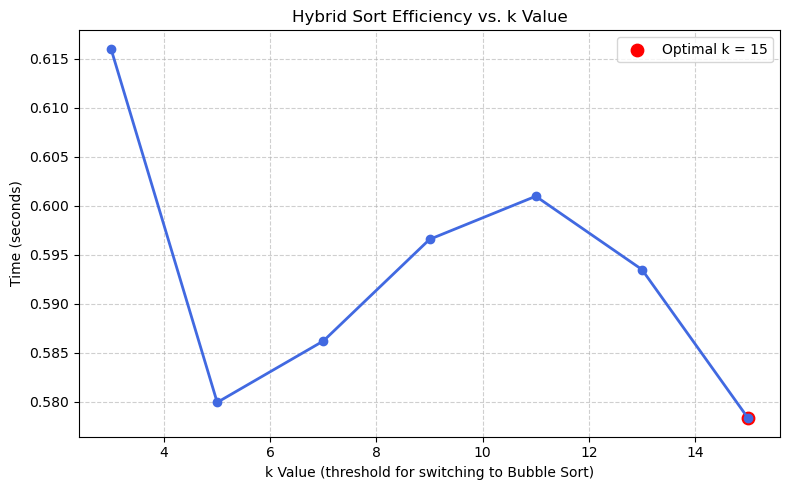

In [31]:
"""
Author: Yaseer Sabir
Description:
    This program visualizes how the time efficiency of the hybrid
    QuickSort + Optimized Bubble Sort algorithm changes with different k values.
    It uses matplotlib to create a line graph of k vs. runtime.
"""

import random
import time
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Optimized Bubble Sort
# -------------------------------------------------------------------
def optimized_bubble_sort(arr):
    """Sorts a list using optimized bubble sort (stops early if no swaps)."""
    n = len(arr)
    for i in range(n - 1):
        swapped = False
        for j in range(n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                swapped = True
        if not swapped:
            break
    return arr


# -------------------------------------------------------------------
# Hybrid QuickSort
# -------------------------------------------------------------------
def hybrid_quicksort(arr, k):
    """Sorts an array using QuickSort but switches to Bubble Sort for small subarrays."""
    if len(arr) <= 1:
        return arr
    if len(arr) <= k:
        return optimized_bubble_sort(arr)

    pivot = arr[len(arr) // 2]
    left = [x for x in arr if x < pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]

    return hybrid_quicksort(left, k) + middle + hybrid_quicksort(right, k)


# -------------------------------------------------------------------
# Helper function to verify sorting
# -------------------------------------------------------------------
def is_sorted(arr):
    """Checks if a list is sorted."""
    for i in range(len(arr) - 1):
        if arr[i] > arr[i + 1]:
            return False
    return True


# -------------------------------------------------------------------
# Run Simulation and Plot
# -------------------------------------------------------------------
if __name__ == "__main__":
    print("Running hybrid sort and plotting time efficiency vs. k...\n")

    # Generate random data (smaller dataset for demonstration)
    original_data = [random.randint(1, 1_000_000) for _ in range(100_000)]

    # Try a range of k values
    k_values = [3, 5, 7, 9, 11, 13, 15]
    times = []

    for k in k_values:
        data_copy = original_data.copy()
        print(f"Testing k={k}...")
        start = time.time()
        sorted_data = hybrid_quicksort(data_copy, k)
        end = time.time()

        if not is_sorted(sorted_data):
            print(f"Warning: data not sorted correctly for k={k}")
        else:
            elapsed = end - start
            times.append(elapsed)
            print(f"Completed in {elapsed:.4f} seconds.\n")

    # -------------------------------------------------------------------
    # Plotting the results
    # -------------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, times, marker='o', color='royalblue', linewidth=2)
    plt.title("Hybrid Sort Efficiency vs. k Value")
    plt.xlabel("k Value (threshold for switching to Bubble Sort)")
    plt.ylabel("Time (seconds)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()

    # Highlight the optimal point
    min_index = times.index(min(times))
    plt.scatter(k_values[min_index], times[min_index], color='red', s=80, label=f"Optimal k = {k_values[min_index]}")
    plt.legend()

    # Show the plot
    plt.show()



In [32]:

"""
Author:Yaseer Sabir
Description:
    A toy Unix "find"-like command implemented in Python using structural recursion.

    Usage:
        $ ./myFind.py <starting_directory> <substring_to_search>

    This program recursively searches through all subdirectories starting from
    <starting_directory> and prints full paths of all files whose names contain
    <substring_to_search>.

    It only counts the total file size (in bytes) of regular files, ignoring
    directories, symbolic links, sockets, etc.

Requirements:
    - Must NOT use os.walk() or any built-in tree traversal.
    - Must use os and stat libraries.
    - Must use a callback function for total file size computation.
"""

import os
import stat
import sys


# ---------------------------------------------------------------------
# Callback function to accumulate total size
# ---------------------------------------------------------------------
def add_file_size(total_size, filepath):
    """
    Callback function that adds the file size of a regular file to the total.

    Parameters:
        total_size (list): A single-element list to hold the running total.
        filepath (str): The full path of the file.
    """
    try:
        info = os.stat(filepath)
        mode = info.st_mode
        # Only add if the file is a regular file (not directory, link, etc.)
        if stat.S_ISREG(mode):
            total_size[0] += info.st_size
    except Exception as e:
        print(f"Could not access {filepath}: {e}")


# ---------------------------------------------------------------------
# Recursive function — STRUCTURAL RECURSION
# ---------------------------------------------------------------------
def myFind(directory, substring, callback, total_size):
    """
    Recursively traverses the directory structure to find matching files.

    Parameters:
        directory (str): Starting directory path.
        substring (str): Substring to search for in filenames.
        callback (function): Function to handle file size counting.
        total_size (list): Mutable container for total file size.
    """
    try:
        entries = os.listdir(directory)  # list of files/subdirectories
    except PermissionError:
        # Skip directories we don't have permission to read
        return
    except FileNotFoundError:
        return

    for entry in entries:
        full_path = os.path.join(directory, entry)
        try:
            info = os.stat(full_path)
        except FileNotFoundError:
            continue

        # If it's a directory → recurse into it
        if stat.S_ISDIR(info.st_mode):
            # Structural recursion: the function calls itself for subdirectories
            myFind(full_path, substring, callback, total_size)
        else:
            # It's a file → check if the name contains the substring
            if substring in entry:
                print(f"{full_path}\t{info.st_size:,} bytes")
                # Use callback to accumulate total size
                callback(total_size, full_path)


# ---------------------------------------------------------------------
# Main function (command-line interface)
# ---------------------------------------------------------------------
def main():
    if len(sys.argv) != 3:
        print("Usage: ./myFind.py <starting_directory> <substring_to_search>")
        sys.exit(1)

    start_dir = sys.argv[1]
    substring = sys.argv[2]

    total_size = [0]  # Using list so it’s mutable in recursion

    print(f"\nSearching for files containing '{substring}' under {start_dir}\n")
    myFind(start_dir, substring, add_file_size, total_size)

    print(f"\nTotal file size: {total_size[0]:,} bytes")


if __name__ == "__main__":
    main()



Searching for files containing 'C:\Users\yasee\AppData\Roaming\jupyter\runtime\kernel-7da0643b-d2eb-43da-a68b-4353f7525b55.json' under -f


Total file size: 0 bytes
